# GPU programming for the urban analysis
1. Import PyCUDA module
2. Calculate the shadow distribution
3. Combine the GeoTIFF Format Shadow Maps into a GIF

By Luming Xu, UPenn, Mar 3, 2025

## 1. Prepare the modules

In [1]:
!pip install pycuda
!pip install rasterio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.8/92.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.5 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2025.1-cp311-cp311-linux_x86_64.whl size=660393 sha256=9a1e80d21d2519d425e965152c7af693a11977bf740c57be6d991645c271d050
  Stored in directory: /root/.cache/pip/wheels/77/7e/6c/d2d1451ea6424cdc3d67b36c16fa7111eafdf2034bc3405666
Successfully built pycuda
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 45.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pycuda.compiler import SourceModule
import pycuda
from pycuda import gpuarray
from pycuda import compiler
import pycuda.autoinit             # PyCuda autoinit
import pycuda.driver as cuda       # PyCuda In, Out helpers
import os, os.path
import rasterio as rio
from osgeo import gdal
from osgeo.gdalconst import *
import numpy as np
import rasterio
import time
import math
# Load the Drive helper and mount
from google.colab import drive
import matplotlib.cm as colormap   # Library to plot
import numpy                       # Fast math library
import matplotlib.image as mpimg       # reading images to numpy arrays
import matplotlib.pyplot as plt        # to plot any graph
import scipy.ndimage as ndi            # to determine shape centrality
# matplotlib setup

%matplotlib inline
from pylab import rcParams
rcParams['figure.figsize'] = (8, 8)      # setting default size of plots

print("pycuda installed and ready to use.")

print("%d device(s) found." % cuda.Device.count())
for ordinal in range(cuda.Device.count()):
    dev = cuda.Device(ordinal)
    print ("Device #%d: %s" % (ordinal, dev.name()))
print (cuda)

pycuda installed and ready to use.
1 device(s) found.
Device #0: Tesla T4
<module 'pycuda.driver' from '/usr/local/lib/python3.11/dist-packages/pycuda/driver.py'>


In [22]:
noaa = {
    'Time': ['0800', '0900', '1000', '1100', '1200', '1300', '1400', '1500', '1600', '1700', '1800'],
    'sun_azimuth': [93.76, 104.85, 119.64, 141.98, 175.62, 211.21, 236, 252.08, 263.83, 273.63, 282.74],
    'sun_elevation': [32.84, 44.2, 54.83, 63.58, 67.82, 65.07, 57.06, 46.7, 35.47, 23.99, 12.65]
}

Mount to your Google Drive

In [25]:
# This will prompt for authorization.
drive.mount('/content/drive')

# replace "deeplearn-city/treepedia-workshop" by your own drive path
dsm_file = "/content/drive/MyDrive/Colab Notebooks/data/row11-col17.tif"
os.path.exists(dsm_file)

dsm_dataset = rio.open(dsm_file)

dsm_bounds = dsm_dataset.bounds
dsm_img = dsm_dataset.read(1)
print('The dsm bound is:', dsm_bounds)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The dsm bound is: BoundingBox(left=2712748.0, bottom=259294.0, right=2717948.0, top=264494.0)


## 2. Compute the shadow distribution

In [26]:
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

# Prepare data
dsm = dsm_img.astype(np.float32)
height, width = dsm.shape

# Allocate memory for input DSM and output shadow map
d_dsm = cuda.mem_alloc(dsm_img.nbytes)
d_shadow = cuda.mem_alloc(dsm_img.nbytes)  # Shadow result (boolean)

# Copy DSM to GPU
cuda.memcpy_htod(d_dsm, dsm_img)

# Initialize shadow output array on CPU
shadow_result = np.zeros_like(dsm_img, dtype=bool)

In [14]:
# Define the CUDA kernel for the shadow calculation
kernel_shadow = """
#define PI 3.1415926

__global__ void calculate_shadow(float *dsm, bool *shadow, int width, int height, float cell_size, float sun_azimuth, float sun_elevation) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    // Check if the thread is within the bounds of the image
    if (x >= width || y >= height)
        return;

    int idx = y * width + x;

    // Convert sun azimuth and elevation to radians
    float azimuth_rad = sun_azimuth * 3.14159 / 180.0;
    float elevation_rad = sun_elevation * 3.14159 / 180.0;

    // Direction of the shadow ray based on sun azimuth
    float dx = sin(azimuth_rad);
    float dy = cos(azimuth_rad);
    float dz = tan(elevation_rad);

    // Initial height at the current pixel
    float initial_height = dsm[idx];
    bool in_shadow = false;

    // Trace the shadow ray
    for (float t = cell_size; t < 2000.0f; t += cell_size) { // Limit tracing distance
        int x_offset = x + int(dx * t / cell_size);
        int y_offset = y + int(dy * t / cell_size);

        if (x_offset < 0 || x_offset >= width || y_offset < 0 || y_offset >= height)
            break;  // Out of bounds

        int offset_idx = y_offset * width + x_offset;

        // Calculate height along the ray
        float height_along_ray = initial_height + dz * t;

        // Check if there is a higher point along the path
        if (dsm[offset_idx] > height_along_ray) {
            in_shadow = true;
            break;
        }
    }

    // Store shadow result: 1 for shadow, 0 for no shadow
    shadow[idx] = in_shadow;
}
"""

# Compile the kernel
mod = SourceModule(kernel_shadow)
calculate_shadows = mod.get_function("calculate_shadow")

In [27]:
output_folder = "/content/drive/MyDrive/Colab Notebooks/Shadow"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

for i in range(len(noaa['Time'])):
    time_str = noaa['Time'][i]
    sun_azimuth = noaa['sun_azimuth'][i]
    sun_elevation = noaa['sun_elevation'][i]

    print(f"Processing Time: {time_str}, Azimuth: {sun_azimuth}, Elevation: {sun_elevation}")

    # Allocate memory for shadow output
    d_shadow = cuda.mem_alloc(dsm_img.nbytes)
    shadow_result = np.zeros_like(dsm_img, dtype=bool)

    # Run CUDA kernel
    calculate_shadows(
        d_dsm, d_shadow, np.int32(width), np.int32(height),
        np.float32(1.0), np.float32(sun_azimuth), np.float32(sun_elevation),
        block=block_size, grid=grid_size
    )

    # Synchronize before copying data back
    cuda.Context.synchronize()

    # Copy shadow result back to CPU
    cuda.memcpy_dtoh(shadow_result, d_shadow)

    # Convert shadow map to uint8 format
    binary_shadow = shadow_result.astype(np.uint8)

    # Save shadow output as a GeoTIFF
    output_path = os.path.join(output_folder, f"shadow_{time_str}.tif")

    # Create metadata for GeoTIFF
    out_meta = {
        "driver": "GTiff",
        "dtype": "uint8",
        "width": width,
        "height": height,
        "count": 1,
        "compress": "lzw"
    }

    with rio.open(output_path, "w", **out_meta) as dest:
        dest.write(binary_shadow, 1)

# Free GPU memory for DSM
d_dsm.free()
d_shadow.free()  # Free shadow memory

Processing Time: 0800, Azimuth: 93.76, Elevation: 32.84


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()


Processing Time: 0900, Azimuth: 104.85, Elevation: 44.2
Processing Time: 1000, Azimuth: 119.64, Elevation: 54.83


/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()
/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()


Processing Time: 1100, Azimuth: 141.98, Elevation: 63.58
Processing Time: 1200, Azimuth: 175.62, Elevation: 67.82


/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()
/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()


Processing Time: 1300, Azimuth: 211.21, Elevation: 65.07
Processing Time: 1400, Azimuth: 236, Elevation: 57.06
Processing Time: 1500, Azimuth: 252.08, Elevation: 46.7
Processing Time: 1600, Azimuth: 263.83, Elevation: 35.47


/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()
/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()


Processing Time: 1700, Azimuth: 273.63, Elevation: 23.99
Processing Time: 1800, Azimuth: 282.74, Elevation: 12.65


## 3. Combine the GeoTIFF Format Shadow Maps into a GIF

In [28]:
import glob
import matplotlib.pyplot as plt
import imageio.v2 as imageio

tiff_dir = "/content/drive/MyDrive/Colab Notebooks/Shadow"
output_gif_path = "/content/drive/MyDrive/Colab Notebooks/shadow_analysis.gif"

# Load GeoTIFF files
tiff_files = sorted(glob.glob(os.path.join(tiff_dir, "*.tif")))  # Sort to ensure correct order
frames = []

# Process and create images
for tiff_file in tiff_files:
    with rasterio.open(tiff_file) as src:
        img_array = src.read(1)  # Read the first band
        img_array = np.nan_to_num(img_array)  # Handle NaN values
        img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min())  # Normalize

        # Plot the image
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img_array, cmap='gray')
        ax.axis('off')

        # Save as an image
        temp_img_path = tiff_file.replace(".tif", ".png")
        plt.savefig(temp_img_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

        # Append to frames
        frames.append(imageio.imread(temp_img_path))

# Save GIF
imageio.mimsave(output_gif_path, frames, duration=5, loop=0)  # Adjust duration as needed

print(f"GIF saved at: {output_gif_path}")

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


GIF saved at: /content/drive/MyDrive/Colab Notebooks/shadow_analysis.gif


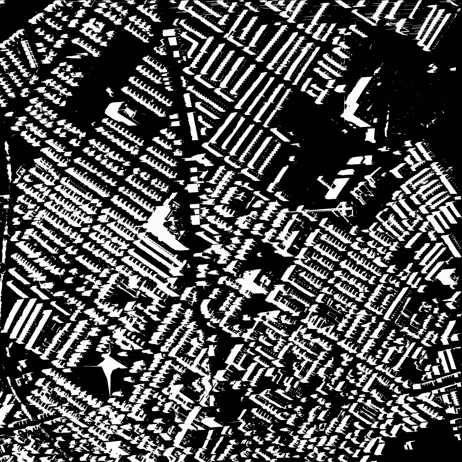

In [29]:
from IPython.display import Image, display

gif_path = "/content/drive/MyDrive/Colab Notebooks/shadow_analysis.gif"
display(Image(filename=gif_path))